In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
# generate artifical data, in reality could be read from a file
nodes = [1, 2, 4]
node_speed = {1 : 1.0, 2 : 0.56, 4 : 0.27}
threads = [1, 2, 4, 8]
thread_speed = {1 : 1.03, 2 : 1.0, 4 : 1.02, 8 : 1.12}
basetime = 1800.0
num_trials = 3

df = pd.DataFrame(columns=['nodes', 'threads', '1' ,'2', '3'])
i = 0
for n, s in node_speed.items():
    for t, f in thread_speed.items():
        var = n * 0.02
        time = basetime * s * f * np.random.uniform(1-var, 1+var, 3)
        row = [n, t] + list(time)
        #print(row)
        df.loc[i] = row
        i += 1
        
df = df.astype({'nodes' : int, 'threads': int})
        

In [60]:
# Calculate variations over different runs
df['max'] = df.iloc[:,-3:].max(axis=1)
df['min'] = df.iloc[:,-3:].min(axis=1)
df['mean'] = df.iloc[:,-3:].mean(axis=1)

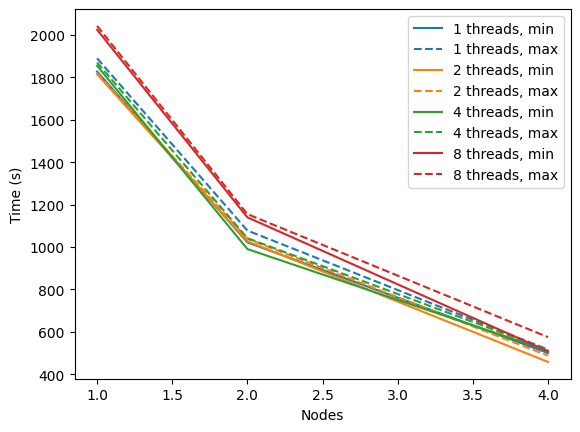

In [70]:
for t in threads:
    d_tmp = df.loc[df['threads'] == t]
    lines = plt.plot(d_tmp['nodes'], d_tmp['min'], '-', label = '{} threads, min'.format(t))
    color = lines[-1].get_color()
    plt.plot(d_tmp['nodes'], d_tmp['max'], color=color, linestyle = '--', label = '{} threads, max'.format(t))

plt.xlabel('Nodes')
plt.ylabel('Time (s)')

plt.legend()

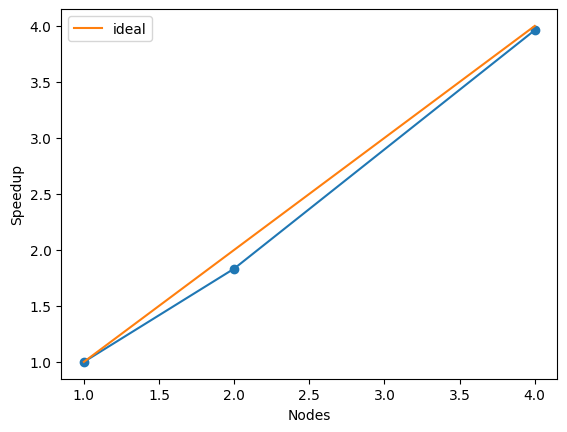

In [80]:
# Maximum speedup
min_times = df.groupby('nodes').agg({'min' : ['min']})
plt.plot(min_times.iloc[0,0] / min_times, 'o-')
# Ideal speedup
plt.plot([min_times.index[0], min_times.index[-1]], [min_times.index[0], min_times.index[-1]], label='ideal')
plt.xlabel('Nodes')
plt.ylabel('Speedup')
plt.legend()
